<div align="center">


# Introducción a Visión Artificial (Computer Vision)

**Definición**

La visión artificial (CV, por su nombre en inglés Computer Vision) es un campo científico interdisciplinario que se ocupa de cómo las computadoras pueden obtener una comprensión de alto nivel a partir de imágenes o videos digitales.

El campo de la visión artificial incluye métodos para adquirir, procesar, analizar y comprender imágenes digitales, y la extracción de datos de alta dimensión del mundo real para producir información numérica o simbólica (por ejemplo: la presencia de un objeto, el movimiento de un objeto, un estado animico de un rostro, etc).

Esta comprensión de la imagen puede verse como la separación de la información simbólica de los datos de la imagen utilizando modelos construidos con la ayuda de la geometría, la física, la estadística y la teoría del aprendizaje.

**Algunas tareas importantes**

<div align="center">
    <img width="600px" src="https://github.com/palasatenea66/DATASETS/raw/main//tareas.png">
</div>

**Clasificación de imágenes**: La tarea de visión artificial por antonomasia: reconocer si una clase predefinida de objetos está presente en una imagen o no.  Hotdog vs not hotdog. Cat vs dog. Cáncer vs no cáncer.

**Localización de objetos**: Típicamente, acompañada de una clasificación. Consiste en decir, dada una imágen, el recuadro en el cual un objeto está presente. Este recuadro se conoce como "bounding box". En esta notebook vamos a hacer reconocimiento de caras (face detection) que es un tipo de localización de objetos

**Detección de objetos**: Es lo mismo que localización, pero permitiendo que haya más de una clase y localizando diferentes individuos.

**Segmentación de imágenes**: Una versión más refinada donde en lugar de obtener una bounding box se obtiene una máscara de pixeles especificando los pixeles especificos que corresponden a un objeto dado en una imágen.

La visión artificial está atravesando un boom y hay muchos subareas específicas con problemas particulares: reconocimiento facial, identificación facial, estimación de pose, detección de landmarks faciales, txt2img, im2img, image captioning, son solo algunas de ellas.

Los **dominios de aplicación**, como se pueden imaginar, son vastos y transversales:
* Inspección automática y procesos de control (por ejemplo, en lineas de montaje)
* Ayudar a los humanos en tareas de identificación, por ejemplo, un sistema de identificación de especies
   * Ver [esta](https://www.kaggle.com/competitions/tensorflow-great-barrier-reef) competencia en Kaggle por ejemplo
* Detectar eventos (vigilancia, conteo de personas, espacios de estacionamiento, tiendas amazon)
* En medicina
* Vehículos autónomos

**Introducción a visión artificial**

En el resto de este curso nos vamos a focalizar en Redes Convolucionales Profundas, una rama del Aprendizaje Profundo que fue la que comenzó la revolución de Deep Learning el 30 de Septiembre de 2012 cuando AlexNet, una red profunda convolucional, ganó el premio ImageNet de ese año, después de años de estancamiento, pisando fuerte: redujo la tasa de error en un 40% comparado con la solución pre-deep learning.

<div align="center">
<img width="400px" src="https://github.com/palasatenea66/DATASETS/raw/main/alexnet.png">
</div>
&nbsp;
&nbsp;
<div align="center">
<img width="400px" src="https://github.com/palasatenea66/DATASETS/raw/main/imagenet.png">
</div>

En esta clase vamos a aprender manipulación básica de imágenes y algunos métodos tradicionales que son fundamentales y nos van a servir como base para ingresar al mundo de las redes profundas aplicado a imágenes.


Como vamos a ver, esta técnicas sencillas son esenciales en la caja de herramientas de cualquier científico de datos que quiera orientarse al procesamiento de imágenes. Por ejemplo, la detección de rostros usando cascadas de Haars es muchas veces más rápida y lo suficientemente buena para ser la preferida en un ambiente productivo por sobre la detección de rostros utilizando técnicas de aprendizaje profundo.

Para esto, vamos a usar la libería `OpenCV`:

<div align="center">
<img src="https://github.com/palasatenea66/DATASETS/raw/main/opencv-logo.png" width="100px" height="130px">
</div>
   
[OpenCV](https://opencv.org/) ("Open Computer Vision") es una librería de código abierto de visión artificial desarrollada originalmente por Intel. Implementada en `C++` pero con APIs en multiples lenguajes, con soporte multiplataforma, es una de las librerías más populares y utilizadas de computer vision. Incluye una gran cantidad de funcionalidad relacionada a la visión artificial, una parte de la cual veremos hoy en esta clase.

En esta clase veremos los siguientes temas:
* Leer, entender y mostrar imágenes
* Espacios de colores
* Métodos de manipulación comunes en Computer Vision
  * Filtro gaussiano
  * Detección de bordes
  * Operaciones simples de manipulación (resize, crop, stacking)
* Figuras geométricas y texto
* Recorte, extracción y rotación
* Detección de caras (Face detection)
* Manejo de Video y Webcam


# Librerías, archivos e importaciones

Instalemos las librerías que necesitamos:

Notar que `OpenCV` se instala como `opencv-python` y se importa como `cv2`, lo cual no es lo mejor.


In [1]:
!pip list | grep opencv

opencv-contrib-python                 4.12.0.88
opencv-python                         4.12.0.88
opencv-python-headless                4.12.0.88


In [2]:
!pip list | grep watermark

In [3]:
!pip install watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.1 MB/s eta 0:00:00


In [4]:
# Importamos las librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import YouTubeVideo

[watermark](https://github.com/rasbt/watermark) es una extensión de las "magic functions" de jupyter que permite verificar fácilmente la versión de python y de las librerías instaladas.
La notebook está probada con:
```python
Python version : 3.7.13
cv2            : 4.6.0
numpy          : 1.21.6
matplotlib     : 3.5.3
```

In [6]:
%load_ext watermark
%watermark
%watermark --iversions

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2025-09-15T23:58:56.055516+00:00

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 7.34.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.1.123+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 2
Architecture: 64bit

numpy     : 2.0.2
cv2       : 4.12.0
matplotlib: 3.10.0
IPython   : 7.34.0



Bajemos también las imagenes y los recursos que vamos a necesitar:

In [7]:
%%capture
!mkdir imgs/
!wget https://github.com/palasatenea66/DATASETS/raw/main/gardel.jpg -O gardel.jpg
!wget https://github.com/palasatenea66/DATASETS/raw/main/lambo.png -O lambo.png
!wget https://github.com/palasatenea66/DATASETS/raw/main/cards.jpg -O cards.jpg
!wget https://github.com/palasatenea66/DATASETS/raw/main/haarcascade_frontalface_default.xml -O haarcascade_frontalface_default.xml
!wget https://unket.s3.sa-east-1.amazonaws.com/data/face_mesh.mp4 -O face_mesh.mp4

In [8]:
!ls

cards.jpg      gardel.jpg			    imgs       sample_data
face_mesh.mp4  haarcascade_frontalface_default.xml  lambo.png


# Leer, entender y mostrar imágenes

Ahora sí, ¡empecemos!

Lo primero que tenemos que hacer es cargar una imagen desde el disco rígido. Para hacerlo, usamos `cv2.imread()`, que la convierte automáticamente a una matriz de `numpy`. Esto es diferente de, por ejemplo, la librería PIL, que levanta las imagenes en un formato específico de la librería. En el mundo de OpenCV vamos a estar trabajando siempre con matrices numéricas de numpy

In [9]:
img = cv2.imread("gardel.jpg")
type(img)

numpy.ndarray

In [10]:
img.shape

(305, 200, 3)

¿Qué son estas dimensiones?

Las primeras dos son el alto (_height_) y el ancho (_width_) de la imagen. En este caso tenemos una imagen de _305_ pixeles de alto por _200_ pixeles de ancho.

El pixel es es la menor unidad homogénea en color que forma parte de una imagen digital. Es un puntito de un color único sólido, el "átomo" del que está hecha la imagen. La forma en que se códifica el color de cada pixel, es usando el conocido espacio de colores RGB con tres números: uno nos va a decir cuánto rojo tiene el pixel, otro cuánto verde y otro cuanto azúl. Rojo, verde y azul son los colores primarios de la luz y componiendolos en términos de intensidad de cada uno de ellos podemos reproducir todo el espectro de colores. Por convención, se usan números entre 0 y 255.

In [11]:
# El pixel de la esquina superior izquierda tiene 16 azul, 22 verde y 27 rojo
# ¿Por qué 16 azul y no 16 de rojo? OpenCV usa BGR, lo aclaramos abajo
img[0, 0]

array([16, 22, 27], dtype=uint8)

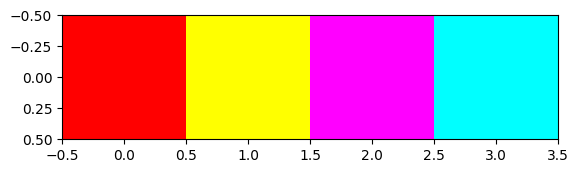

In [12]:
# Acá pueden jugar definiendo pixeles y mostrandolos

# Todo rojo, nada de verde, nada de azul ==> rojo
pixel1 = (255, 0, 0)

# Todo rojo, todo verde, nada de azul ==> amarillo
pixel2 = (255, 255, 0)

# Todo rojo, nada verde, todo azul ==> MAGENTA
pixel3 = (255, 0, 255)

# Verde más azul =cian
pixel4=(0, 255, 255)

plt.imshow([[pixel1, pixel2, pixel3, pixel4]]);

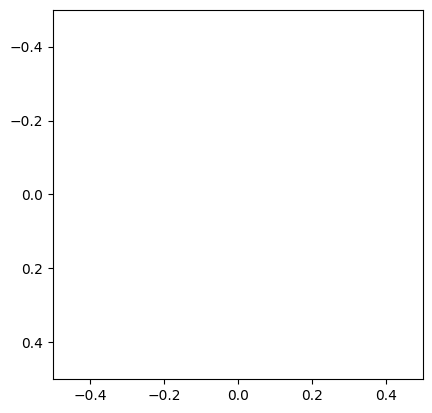

In [13]:
pixel5=(255,255,255)
plt.imshow([[pixel5]])

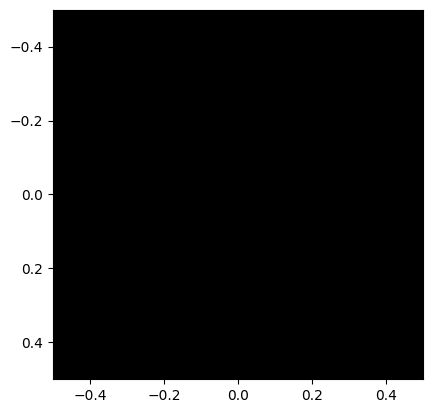

In [14]:
pixel6=(0,0,0)
plt.imshow([[pixel6]])

**Mostrar con OpenCV**

Para mostrar una imagen con opencv usamos `cv2.imshow()`.

OpenCV abre una ventana flotante. Para poder cerrarla nosotros y que no se cierre sola, agregamos un loop que verifica si se presiona una tecla cualquiera y cierra la ventana en ese escenario. El código necesario es un poco técnico, pero es siempre el mismo boilerplate.

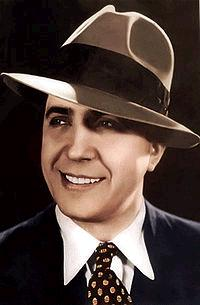

In [15]:
# En google colab cv2.imshow no funciona, se puede usar esto a cambio (se pierde solamente la función de zoom):
from google.colab.patches import cv2_imshow
cv2_imshow(img)

In [16]:
# En instancia local
cv2.imshow("Window", img)

while(True):
    k = cv2.waitKey(0)
    # si ninguna tecla fue presionada, retorna -1
    if k == -1:
        continue
    else:
        break
cv2.destroyAllWindows()

DisabledFunctionError: cv2.imshow() is disabled in Colab, because it causes Jupyter sessions
to crash; see https://github.com/jupyter/notebook/issues/3935.
As a substitution, consider using
  from google.colab.patches import cv2_imshow


Desde una computadora local podemos leer los componentes RGB del píxel superior izquierdo con la función de zoom

**Mostrar con matplotlib**

Como ya adelantamos al mostrar los pixeles, para mostrar una matriz de numpy como una imagen `RGB` con matplotlib, usamos `imshow`.

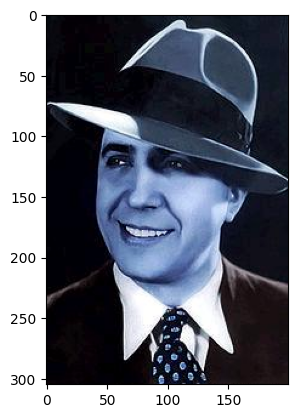

In [17]:
plt.imshow(img);

# Espacios de colores

Ok, la imagen está un poco azul...

Esto es porque opencv trabaja con las imágenes en el espacio de colores BGR (Blue, Green, Red)

Matplotlib, por su parte, como muchas otras librerías, trabaja en RGB (Red, Green, Blue)

Para pasar de un espacio de colores a otro, usamos `cv2.cvtColor()`

In [18]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

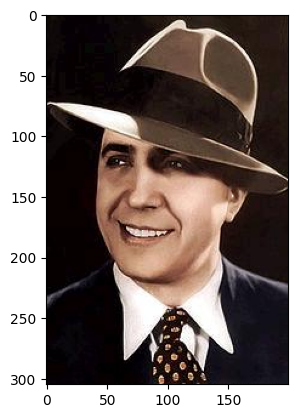

In [19]:
# ¡Ahora sí!
plt.imshow(img_rgb);

Notar que esta transformación no es más que transponer los canales Blue por Red (esto es el primer canal pasarlo al final y el último canal pasarlo al principio), lo que también podemos hacer así:

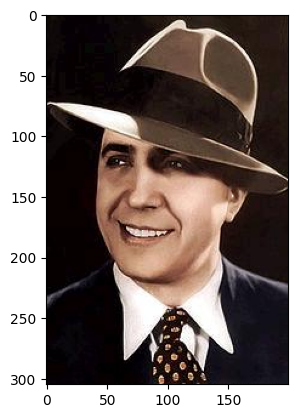

In [20]:
plt.imshow(img[:, :, [2, 1, 0]]);

Pero existen otros espacios de colores... y movernos a ellos no es una transformación tan sencilla.

Por ejemplo, pasar de BGR a escala de grises implica reducir los tres canales de colores a uno solo:

In [21]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_gray.shape

(305, 200)

Para esta transformación, la imagen perdió información y ahora cada pixel es simplemente un número entre 0 y 255 indicando "cuánto de blanco" hay en el pixel:

In [22]:
img_rgb[0:2, 0:2]

array([[[27, 22, 16],
        [24, 19, 13]],

       [[20, 15,  9],
        [17, 12,  6]]], dtype=uint8)

In [23]:
img_gray[0:2, 0:2]

array([[23, 20],
       [16, 13]], dtype=uint8)

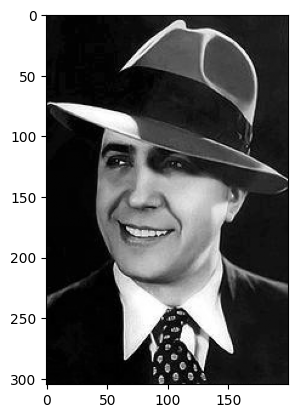

In [24]:
plt.imshow(img_gray, cmap='gray');

Existen [otros espacios de colores](https://es.wikipedia.org/wiki/Espacio_de_color) como el CMYK (Cyan, Magenta, Yellow, Key) utilizado en impresión y el HSV (Hue, Saturation, Value) cuya codificación es a veces mucho más cercana a las intuciones humanas del color.

Todas las transformaciones de espacios de color a otros se hacen con:
`img_dst = cv2.cvtColor(img_src, cv2.COLOR_...)`

# Métodos de manipulación comunes en Computer Vision

## Filtro gaussiano

El filtro gaussiano desenfoca o suaviza la imagen tratada. En inglés se conoce como "blur", "gaussian blur", o "gaussian smoothing".

Es un efecto ampliamente utilizado en procesamiento de imagenes, ya que sirve para suavizar los bordes y eliminar ruido, aun con el costo evidente de una pérdida de nitidez y de un aumento de indefinición de las formas. En concreto, el filtro mezcla ligeramente los colores de los píxeles vecinos unos con otros, logrando esta perdida de detalle caracteristica del desenfoque.

El filtrado gaussiano se utiliza comunmente como un paso previo a la detección de bordes, ya que los algoritmos de detección de bordes son muy sensibles al ruido.

Para utilizar esta técnica, usamos la funcion `cv2.GaussianBlur()`, que recibe como primer parámetro la imagen que queremos desenfocar y, como segundo parametro, una tupla con dos números que deben ser impares. A más grande estos números, mayor el nivel de desenfoque.

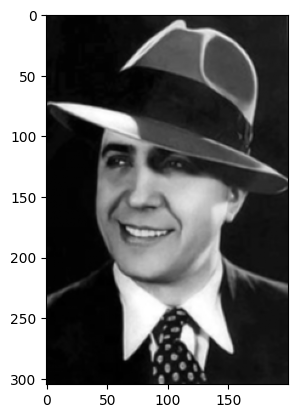

In [36]:
img_blur = cv2.GaussianBlur(img_gray, (3,3), 0)
plt.imshow(img_blur, cmap='gray');

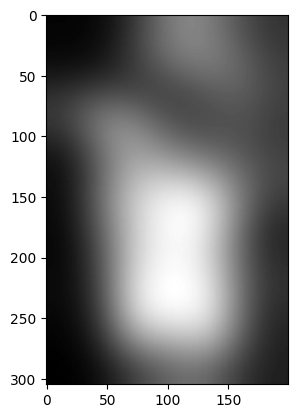

In [35]:
img_blur = cv2.GaussianBlur(img_gray, (155, 155), 0)
plt.imshow(img_blur, cmap='gray');

## Detección de bordes

La función de detección de bordes nativa de OpenCV utiliza el [Algoritmo de Canny](https://es.wikipedia.org/wiki/Algoritmo_de_Canny), una conocida técnica multi-etapa inventada por John F. Canny en 1986. La primera etapa de este algoritmo es un filtrado gaussiano de tamaño (5, 5) - no hace falta hacerla previamente porque el proceso la hace automáticamente.

Para usar esta función llamamos a [`cv2.Canny()`](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html). El primer parámetro es la imagen en la que queremos detectar los bordes. El segundo y el tercer parámetro configuran la sensibilidad del algoritmo. Valores típicos son: `(100, 200)`, `(50, 100)`, `(150, 200)`. El tercero debe ser más alto que el primero (uno es un mínimo y otro es un máximo). Valores bajos harán al algoritmo más sensible (esto es, detectará más bordes) y valores más altos harán que detecte menos bordes.

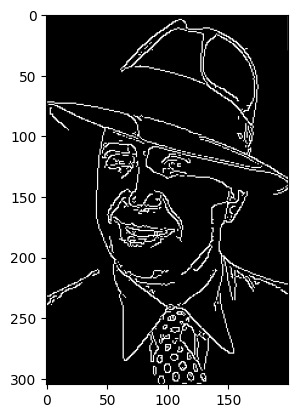

In [42]:
img_canny = cv2.Canny(img_gray, 100, 200)
plt.imshow(img_canny, cmap='gray');

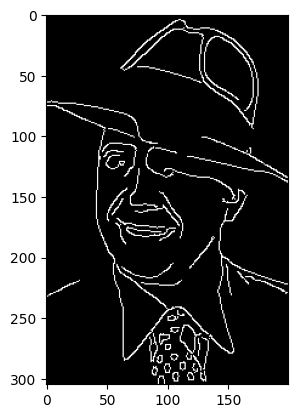

In [41]:
# Podemos ver que agregando un blureado extra
# podemos ayudar al algoritmo a reducir bordes excesivos (por ejemplo, en la zona del sombrero)
img_extra_blur_canny = cv2.Canny(cv2.GaussianBlur(img_gray, (7, 7), 0), 100, 200)
plt.imshow(img_extra_blur_canny, cmap='gray');

Finalmente, podemos usar la función `cv2.dilate` para expandir estos bordes y ganar más visibilidad:

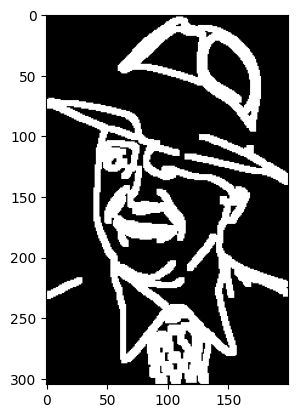

In [44]:
kernel = np.ones((5, 5))
img_dilation = cv2.dilate(img_extra_blur_canny, kernel, iterations=1)
plt.imshow(img_dilation, cmap='gray');


## Operaciones simples de manipulación

**cv2.resize()**

Para cambiar de tamaño una imagen usamos `cv2.resize`

In [45]:
img = cv2.imread("lambo.png")
img.shape

(462, 623, 3)

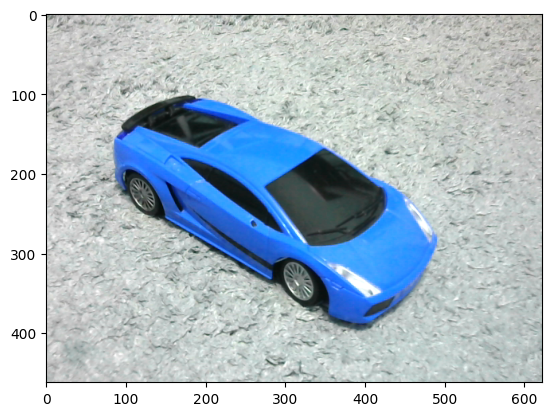

In [46]:
plt.imshow(img);

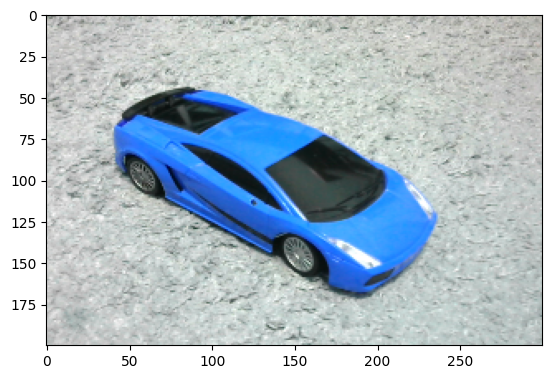

In [47]:
# En resize especificamos primero ancho y despues alto
img_resize = cv2.resize(img, (300, 200))
plt.imshow(img_resize);

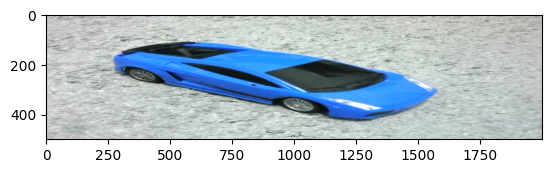

In [48]:
# Primero ancho y despues alto
img_resize2 = cv2.resize(img, (2000, 500))
plt.imshow(img_resize2);

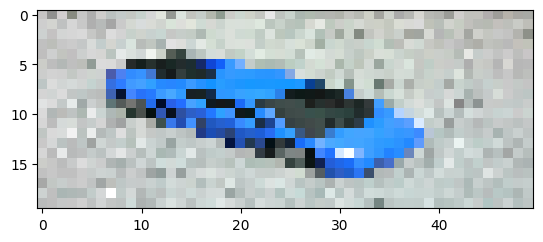

In [49]:
# Primero ancho y despues alto
img_resize2 = cv2.resize(img, (50, 20))
plt.imshow(img_resize2);

In [50]:
# En los arrays el alto viene primero y el ancho viene despues
img_resize2.shape

(20, 50, 3)

**Recortar / croppear**

Recortar un sector de una imagen es sencillo, considerando que son arrays simplemente los indexamos

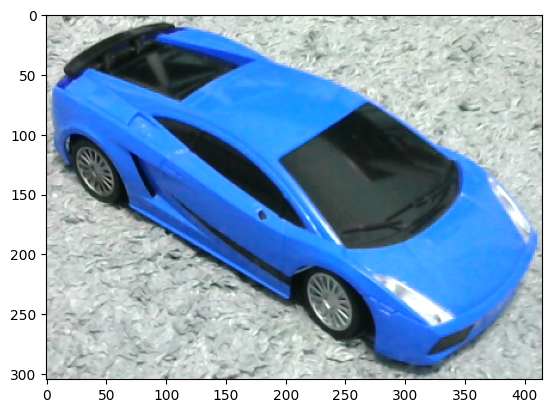

In [51]:
# Primero alto, despues ancho
img_cropped = img[95:400, 80:495]
plt.imshow(img_cropped);

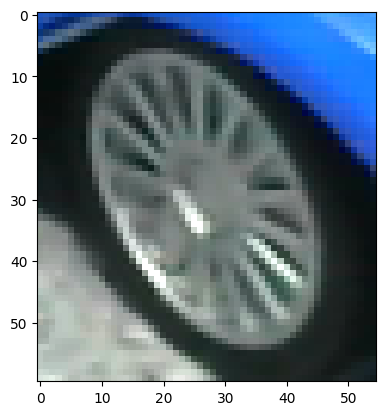

In [52]:
img_cropped = img[305:365, 290:345]
plt.imshow(img_cropped);

**Apilado / stacking**

El apilado no es una técnica de imagenes sino de matrices, pero sirve para imagenes también. Podemos apilar horizontalmente con `np.hstack()` y verticalmente con `np.vstack()`

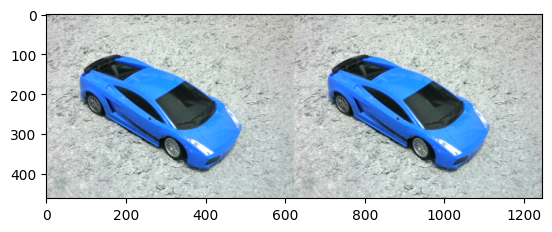

In [53]:
# Apilado horizontal
hor = np.hstack((img, img))
plt.imshow(hor);

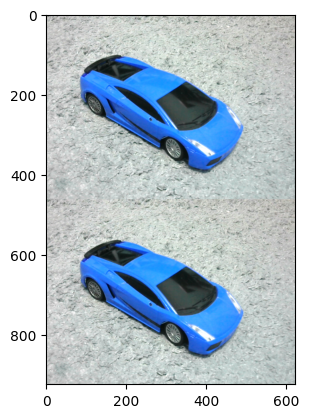

In [54]:
# Apilado vertical
ver = np.vstack((img, img))
plt.imshow(ver);

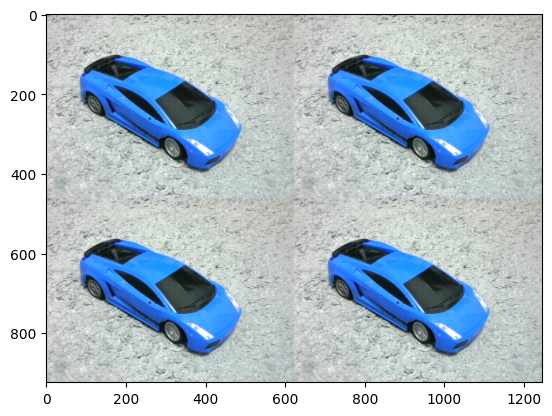

In [55]:
# Apilamos horizontamente dos filas, generando una "matriz" de 2x2
hor2 = np.hstack((ver, ver))
plt.imshow(hor2);

# Figuras geométricas y texto

En esta sección vamos a aprender a dibujar lineas, círculos, puntos, rectángulos (vacíos o rellenos) y a agregar texto a las imágenes.

Lo vamos a hacer sobre un fondo negro para entender mejor. Luego podrán aplicar estas técnicas sobre imagenes concretas (por ejemplo, usando rectángulos para encuadrar objetos o puntos para identificar alguna posición)

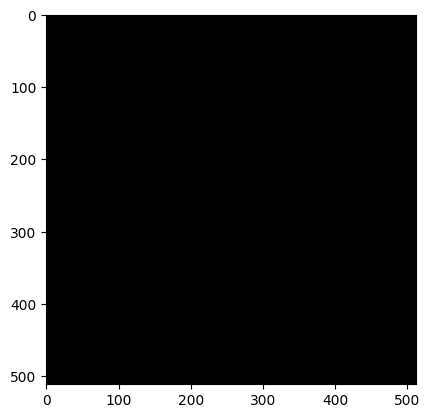

In [62]:
# Tapiz negro RGB de 512x512
img = np.zeros((512, 512, 3), np.uint8)
plt.imshow(img, cmap='gray');

** Linea**

Para agregar una linea recta usamos `cv2.line()` con los siguientes parametros:
* img: la imagen a la que agregaremos la linea
* pt1: una tupla con las coordenadas en pixeles de donde empieza la linea. Por ejemplo: (0, 0)
* pt2: una tupla con las coordenadas en pixeles de donde termina la linea. Por ejemplo: (10, 50)
* color: una tupla con el color (r, g, b)
* thickness: el ancho de la linea

En este ejemplo, trazamos una linea verde desde la esquina superior izquierda (0,0) al punto (300, 300)

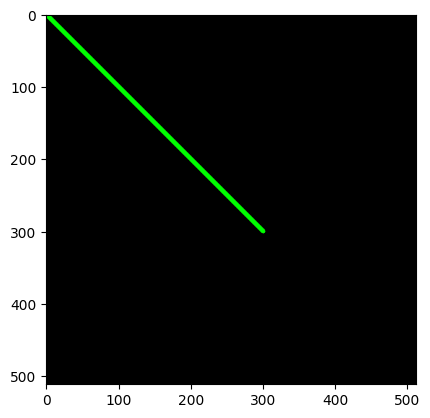

In [63]:
cv2.line(img, pt1=(0, 0), pt2=(300, 300), color=(0, 255, 0), thickness=5)
plt.imshow(img);

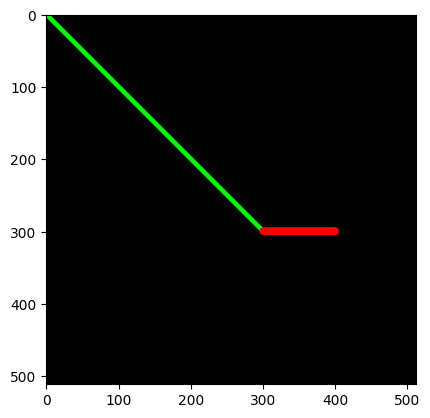

In [64]:
# Acá creamos una linea roja horizontal de 100 pixeles desde el vertice de la linea anterior
# Esta es 2 veces más ancha que la verde
cv2.line(img, pt1=(300, 300), pt2=(400, 300), color=(255, 0, 0), thickness=10)
plt.imshow(img);

**Rectángulo**

Para agregar un rectángulo usamos `cv2.rectangle()` con los mismos parametros que usa `cv2.line`. Los dos puntos elegidos, en lugar de definir una linea, van a usarse como dos esquinas del rectángulo:

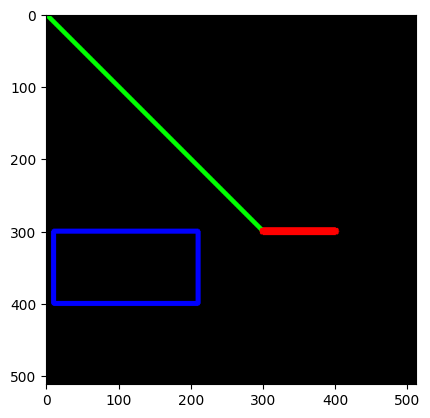

In [65]:
cv2.rectangle(img, (10, 300), (210, 400), (0, 0, 255), 5)
plt.imshow(img);

**Rectángulo relleno**

Para que esté relleno a "thickness" le pasamos de parametro `cv2.FILLED`

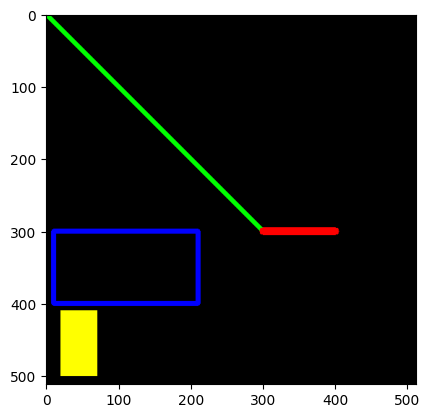

In [66]:
cv2.rectangle(img, (20, 410), (70, 500), (255, 255, 0), cv2.FILLED)
plt.imshow(img);

**Círculo**

Para agregar un círculo usamos `cv2.circle` con parámetros:
* img: la imagen a la que agregaremos la linea
* center: tupla con las coordenadas en pixeles de el centro del círculo
* radius: longitud en pixeles del radio del círculo
* color: una tupla con el color (r, g, b)
* thickness: el ancho de la linea

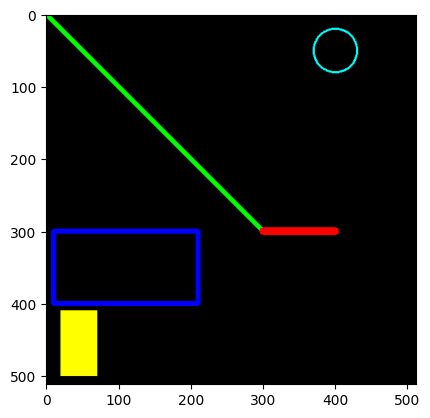

In [67]:
cv2.circle(img, center=(400, 50), radius=30, color=(0, 255, 255), thickness=2)
plt.imshow(img);

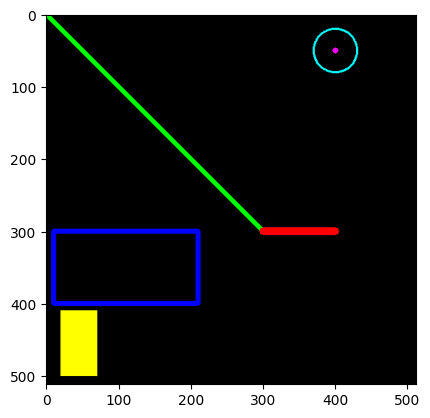

In [68]:
# Un circulo de radio 1 es un punto
cv2.circle(img, center=(400, 50), radius=1, color=(255, 0, 255), thickness=5)
plt.imshow(img);

**Texto**
Para agregar texto usamos `cv2.putText()`.

* img: la imagen a la que agregaremos la linea
* text: el texto a agregar
* org: un punto. especifica la esquina inferior izquierda del texto
* fuente: una de las opciones bajo `cv2.FONT_...`
* tamaño de fuente: 1 es un tamaño razonable, puede ser inferior a 1 para tamaños más chicos
* color: una tupla con el color (r, g, b)
* thickness: el ancho de la linea

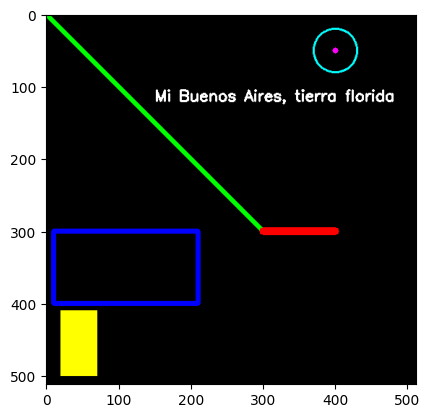

In [69]:
cv2.putText(img, "Mi Buenos Aires, tierra florida", (150, 120),  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
plt.imshow(img);

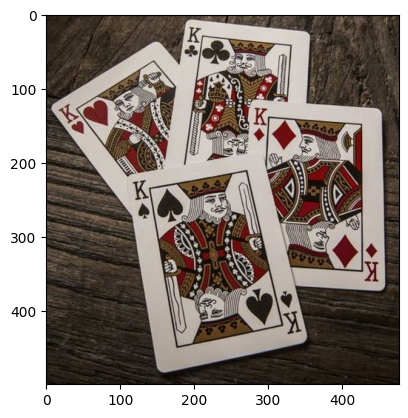

In [70]:
# Comencemos abriendo la imagen
img = cv2.cvtColor(cv2.imread("cards.jpg"), cv2.COLOR_BGR2RGB)
plt.imshow(img);

# Recorte, extracción y cambio de perspectiva

En esta sección vamos a recortar una de las cartas, extraerla y rotarla para que se vea de frente.

Para eso vamos a:

1. Identificar las cuatros esquinas de la carta en cuestión (Vamos a extraer el rey de picas del frente y rotarlo).
2. Crear una matriz de transformación de cambio perspectiva. Para esto especificaremos los puntos 4 puntos de origen y los 4 puntos de destino y vamos a llamar a `cv2.getPerspectiveTransform(pts1, pts2)` que va a construir la matriz que nos va a servir para realizar esta transformación


<div align="center">
<img src="https://github.com/palasatenea66/DATASETS/raw/main/cambio-perspectiva.png" width="500px" height="130px">
</div>

3. Finalmente, vamos a aplicarla con `cv2.wrapPerspective()`, que va a extraer el area delimitada en la imagen original y aplicar la matriz de cambio de perspectiva para generar una imagen única recortada y con una nueva alineación.



In [71]:
img.shape

(500, 477, 3)

Ahora vamos a identificar, a ojo, las coordenadas de las esquinas de la carta que queremos extraer y cambiar de perspectiva:

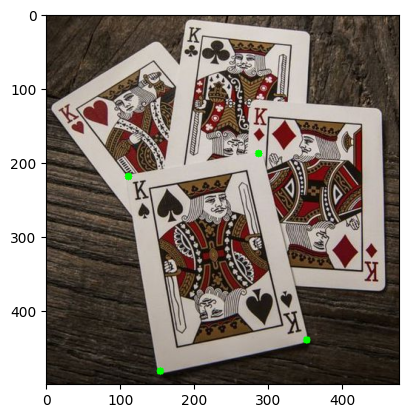

In [72]:
# Primero coordenada x, despues coordenada y
corners = [(111, 219), # Superior izquierdo
           (287, 188), # Inferior izquierdo
           (154, 482), # Superior derecho
           (352,  440) # Inferior derecho
          ]

for x, y in corners:
    cv2.circle(img, (x,y), radius=0, color=(0, 255, 0), thickness=10)
plt.imshow(img);

Creamos la matriz de cambio de perspectiva. Para eso, especificamos los puntos originales y a donde va a ir cada uno en la imagen final. Debemos decidir el tamaño de la imagen final

In [73]:
w, h = 250, 350

In [74]:
pts1 = np.float32(corners)
# Para los puntos de destino, debe preservarse el orden de los puntos originales
pts2 = np.float32([[0, 0], [w, 0], [0, h], [w, h]])

In [75]:
# Obtenemos la matriz de cambio de perspectiva
matrix = cv2.getPerspectiveTransform(pts1, pts2)

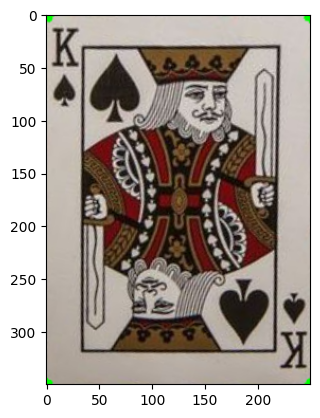

In [76]:
# Y la aplicamos con warpPerspective
# El segundo parametro es esta matriz y el tercero debe ser una tupla con especificando (ancho, alto)
img_output = cv2.warpPerspective(img, matrix, (w, h))
plt.imshow(img_output);

# Detección de caras (Face detection)

La detección de caras es un caso específico de la detección de objetos. En este caso, lo que se busca encontrar y localizar es un rostro humano.

El estado de arte hoy está dominado por redes convolucionales profundas. Sin embargo, un algoritmo de la era previa, inventado en 2001, es lo suficientemente efectivo y, además, muy liviano y veloz, para preservarse en uso en la actualidad y hacer frente a la competencia de las redes profundas. Estamos hablando del [algoritmo de Viola & Jones](https://www.merl.com/publications/docs/TR2004-043.pdf), con cascadas de HAAR, que es el que se usa nativamente en `OpenCV`.

Si bien en la práctica la división de una imagen en subrregiones se suele computar en paralelo, podemos pensar en el concepto de ventana deslizante para entender cómo funciona esta técnica. Dada una imagen, la recorremos con una ventana deslizante de un tamaño fijo y vamos extrayendo recortes. Sobre cada uno de estos recortes vamos a intentar decidir si contiene una cara o no. Este procedimiento lo podemos hacer con ventanas de diferentes tamaños:

<div align="center">
<img src="https://github.com/palasatenea66/DATASETS/raw/main/slidding_tec.png" width="100px" height="150px">
</div>





Ahora, el problema se resume a, dado un recorte del tamaño de una cara, decidir si hay una cara o no. Para esto, el algoritmo extrae caracteristicas de este recorte, las características de Haar (su nombre se debe a su similitud con unas ondas llamadas ondas de Haar).

Una característica de Haar consiste esencialmente en cálculos que se realizan en regiones rectangulares adyacentes en una ubicación específica de la ventana de detección. El cálculo implica sumar las intensidades de píxeles en cada región y calcular las diferencias entre esas sumas. Estos son algunos ejemplos de características de Haar:

<div align="center">
<img src="https://miro.medium.com/max/428/1*yl-BqUzycbyfhPAzwWOddQ.png" width="250px" height="250px">
</div>

Un paso que aquí obviaremos es el cálculo de la imagen integral, que se utiliza para acelerar el tiempo de computo de las caracteristicas de Haar de las regiones.


El último paso es la utilización de una "cascada" de algoritmos de clasificación (AdaBoost) construidos sobre diferentes caracteristicas de Haar. En el primer paso, se verifican ciertas caracteristicas. Si el clasificador produce una baja probabilidad de que haya un rostro, el recorte se descarta inmediatamente, evitando malgastar tiempo en regiones de la imagen sin rostro. Esto es fundamental, ya que típicamente una imagen tendrá muy pocos recortes con presencia de rostros y gastar computo en descartarlos volvería al algoritmo muy lento. En el caso en que el primer paso produzca una probabilidad buena, se pasa al siguiente clasificador, que, nuevamente, tiene poder de veto sobre el recorte.

En el video podemos ver cómo los recortes sin rostro son descartados con poco costo, mientras que en las regiones donde se encuentra un rostro el algoritmo se detiene y avanza más pasos, dedicando más recursos: computando más características de Haar y evaluando subsecuentes clasificadores.

Si el recorte logra atravesar toda la cascada de clasificadores sin ser descartado, entonces una cara fue encontrada.

Este procedimiento, con diferentes clasificadores y diferentes características de Haar se utiliza para otro tipo de detección de objetos, no solo para rostros.

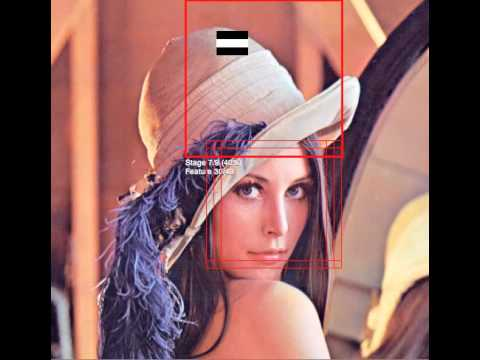

In [77]:
YouTubeVideo("hPCTwxF0qf4")

¡Apliquemoslo!

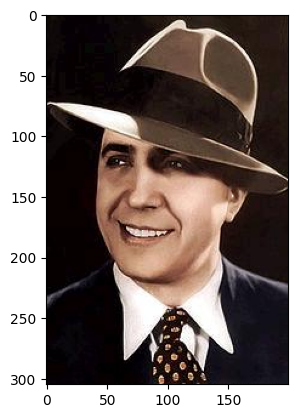

In [78]:
img = cv2.imread("gardel.jpg")
plt.imshow(img[:, :, [2, 1, 0]]);

In [79]:
# El algoritmo de cascadas de Haar funciona sobre imagenes en escala de grises
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Instanciamos el objeto con la definiciones relevantes a deteccion de rostros
# Como dijimos anteriormente, este "Cascade Classifier" puede usarse para detectar otro tipo de objetos
face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

# Finalmente, aplicamos el detector a la imagen
faces = face_cascade.detectMultiScale(img_gray)
# Obtenemos una cara
len(faces)

1

In [80]:
faces

array([[ 21,  79, 115, 115]], dtype=int32)

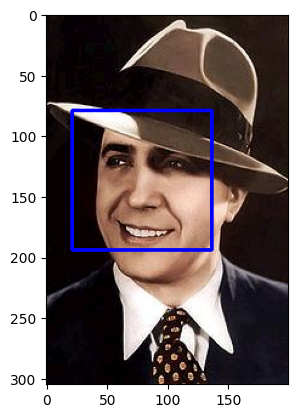

In [81]:
# El resultado consiste de 4 numeros, los dos primeros especificando
# la esquina superior izquierda de la region en la que se detectó un restros
# Y los siguiente el ancho y el alto de la region

x, y, w, h = faces[0]

# Lo graficamos usando cv2.rectangle

cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
plt.imshow(img[:, :, [2, 1, 0]]);

# Manejo de Video y Webcam

**Archivo de video**

Para cerrar, veremos cómo manipular un archivo de video o una webcam con opencv.

Ambos casos son idénticos: vamos a crear un objeto `cv2.VideoCapture()`. Este objeto tiene tiene un método `.read()`, que retorna dos variables. La primera es un booleano (`success`) que nos dice si la lectura del próximo frame tuvo éxito y la segunda es el frame obtenido.

Este objeto enmascara la complejidad de la codificación de, por ejemplo, un mp4, y nos permite imaginarlo como una secuencia de imágenes.

Veamos cómo funciona esto con un video:

In [82]:
# Creamos el objeto
cap = cv2.VideoCapture("face_mesh.mp4")

In [83]:
# En colab usar:

from google.colab.patches import cv2_imshow

In [ ]:

# En la local se puede ver todo el video con while True:
while True:
# En colab veamos solo los primeros 10 frames:
#for i in range(10):
    # Leemos de a un frame
    success, img = cap.read()
    # Si se termino el video, salimos
    if not success: break

    # Sino, ¿qué hacemos?
    # Podemos hacer varias cosas...
    #img_canny = cv2.Canny(img, 100, 200)

    # En local podemos usar esto:
    #cv2.imshow("Video", img)

    # En colab usar:
    # Notar que solo imprimira una imagen detrás de la otra al display
    cv2_imshow(img)

    # En el caso de los videos, esta sección tiene una doble funcionalidad
    # Por un lado, permite salir si se presiona una tecla
    # Por otro, marca el tempo de reproducción del video
    # El 100 son 100 ms que se espera entre frame y frame
    # Se puede tocar para que vaya más lento o más rapido
    #if cv2.waitKey(int(1000/38)) != -1:
    #   break
cv2.destroyAllWindows()

**Webcam**

Una webcam funciona exactamente igual que un video. En lugar de pasarle el nombre del archivo, vamos a pasarle un número del dispositivo. La webcam nativa de la notebook es típicamente el dispositivo `0`.

La webcam funciona como un archivo de video infinito.

### En colab

Código tomado de https://colab.research.google.com/drive/1QnC7lV7oVFk5OZCm75fqbLAfD9qBy9bw#scrollTo=1nkSnkbkk4cC

In [ ]:
#@title Función para mostrar webcam en colab

from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import PIL
import io
import numpy as np


# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
    """
    Params:
          js_reply: JavaScript object containing image from webcam
    Returns:
          img: OpenCV BGR image
    """
    # decode base64 image
    image_bytes = b64decode(js_reply.split(',')[1])
    # convert bytes to numpy array
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    # decode numpy array into OpenCV BGR image
    img = cv2.imdecode(jpg_as_np, flags=1)

    return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
    """
    Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
    Returns:
        bytes: Base64 image byte string
    """
    # convert array into PIL image
    bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
    iobuf = io.BytesIO()
    # format bbox into png for return
    bbox_PIL.save(iobuf, format='png')
    # format return string
    bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

    return bbox_bytes

# JavaScript to properly create our live video stream using our webcam as input
def video_stream():
    js = Javascript('''
        var video;
        var div = null;
        var stream;
        var captureCanvas;
        var imgElement;
        var labelElement;

        var pendingResolve = null;
        var shutdown = false;

        function removeDom() {
           stream.getVideoTracks()[0].stop();
           video.remove();
           div.remove();
           video = null;
           div = null;
           stream = null;
           imgElement = null;
           captureCanvas = null;
           labelElement = null;
        }

        function onAnimationFrame() {
          if (!shutdown) {
            window.requestAnimationFrame(onAnimationFrame);
          }
          if (pendingResolve) {
            var result = "";
            if (!shutdown) {
              captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
              result = captureCanvas.toDataURL('image/jpeg', 0.8)
            }
            var lp = pendingResolve;
            pendingResolve = null;
            lp(result);
          }
        }

        async function createDom() {
          if (div !== null) {
            return stream;
          }

          div = document.createElement('div');
          div.style.border = '2px solid black';
          div.style.padding = '3px';
          div.style.width = '100%';
          div.style.maxWidth = '600px';
          document.body.appendChild(div);

          const modelOut = document.createElement('div');
          modelOut.innerHTML = "<span>Status:</span>";
          labelElement = document.createElement('span');
          labelElement.innerText = 'No data';
          labelElement.style.fontWeight = 'bold';
          modelOut.appendChild(labelElement);
          div.appendChild(modelOut);

          video = document.createElement('video');
          video.style.display = 'block';
          video.width = div.clientWidth - 6;
          video.setAttribute('playsinline', '');
          video.onclick = () => { shutdown = true; };
          stream = await navigator.mediaDevices.getUserMedia(
              {video: { facingMode: "environment"}});
          div.appendChild(video);

          imgElement = document.createElement('img');
          imgElement.style.position = 'absolute';
          imgElement.style.zIndex = 1;
          imgElement.onclick = () => { shutdown = true; };
          div.appendChild(imgElement);

          const instruction = document.createElement('div');
          instruction.innerHTML =
              '<span style="color: red; font-weight: bold;">' +
              'When finished, click here or on the video to stop this demo</span>';
          div.appendChild(instruction);
          instruction.onclick = () => { shutdown = true; };

          video.srcObject = stream;
          await video.play();

          captureCanvas = document.createElement('canvas');
          captureCanvas.width = 640; //video.videoWidth;
          captureCanvas.height = 480; //video.videoHeight;
          window.requestAnimationFrame(onAnimationFrame);

          return stream;
        }
        async function stream_frame(label, imgData) {
          if (shutdown) {
            removeDom();
            shutdown = false;
            return '';
          }

          var preCreate = Date.now();
          stream = await createDom();

          var preShow = Date.now();
          if (label != "") {
            labelElement.innerHTML = label;
          }

          if (imgData != "") {
            var videoRect = video.getClientRects()[0];
            imgElement.style.top = videoRect.top + "px";
            imgElement.style.left = videoRect.left + "px";
            imgElement.style.width = videoRect.width + "px";
            imgElement.style.height = videoRect.height + "px";
            imgElement.src = imgData;
          }

          var preCapture = Date.now();
          var result = await new Promise(function(resolve, reject) {
            pendingResolve = resolve;
          });
          shutdown = false;

          return {'create': preShow - preCreate,
                  'show': preCapture - preShow,
                  'capture': Date.now() - preCapture,
                  'img': result};
        }
        ''')

    display(js)

def video_frame(label, bbox):
    data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
    return data

In [ ]:
# start streaming video from webcam
video_stream()
# label for video
label_html = 'Capturing...'
# initialze bounding box to empty
bbox = ''
count = 0
while True:
    js_reply = video_frame(label_html, bbox)
    if not js_reply:
        break

    # convert JS response to OpenCV Image
    img = js_to_image(js_reply["img"])

    # create transparent overlay for bounding box
    bbox_array = np.zeros([480,640,4], dtype=np.uint8)

    # grayscale image for face detection
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # get face region coordinates
    face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
    faces = face_cascade.detectMultiScale(gray)
    # get face bounding box for overlay
    for (x,y,w,h) in faces:
          bbox_array = cv2.rectangle(bbox_array,(x,y),(x+w,y+h),(255,0,0),2)

    bbox_array[:,:,3] = (bbox_array.max(axis=2)>0 ).astype(int) * 255
    # convert overlay of bbox into bytes
    bbox_bytes = bbox_to_bytes(bbox_array)
    # update bbox so next frame gets new overlay
    bbox = bbox_bytes

<IPython.core.display.Javascript object>

MessageError: NotAllowedError: Permission denied

### En jupyter notebook fuera de colab:

In [ ]:
# Todo igual que con el mp4

DEVICE = 0
cap = cv2.VideoCapture(DEVICE)

while True:

    success, img = cap.read()

    if not success: break

    #img = cv2.Canny(img, 200, 300)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
    faces = face_cascade.detectMultiScale(img_gray, 1.1, 4)
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    cv2.putText(img, "Me encanta OpenCV", (150, 120),  cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    cv2.imshow("Video", img)

    # Como no queremos agregar delay, acá dejamos 1ms
    if cv2.waitKey(1) != -1:
        break

# Para la webcam, hay que agregar este cap.release() para liberar el dispositivo
cap.release()
cv2.destroyAllWindows()